# Problem Types

QLauncher provides a set of definitions of predefined combinatorial problems ready to use. Featured problems include Exact Cover, Graph Coloring, Job Shop Scheduling Problem, Max Cut, Quantum Air Traffic Management and Traveling Salesperson Problem.

In [1]:
import os

from qlauncher.problems import EC, JSSP, QATM, TSP, GraphColoring, MaxCut, VertexCover

You can create you own problem instance but QLauncher provides also example instances allowing to quickly test functionality.

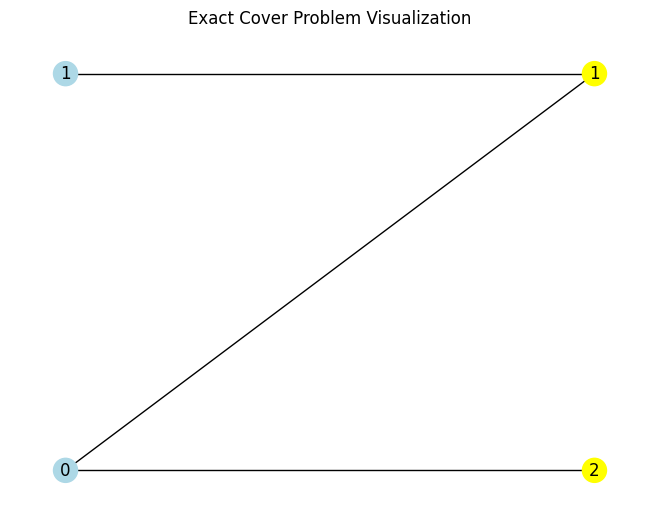

In [2]:
instance = [{1, 2}, {1}]
ec = EC(instance)
ec.visualize()

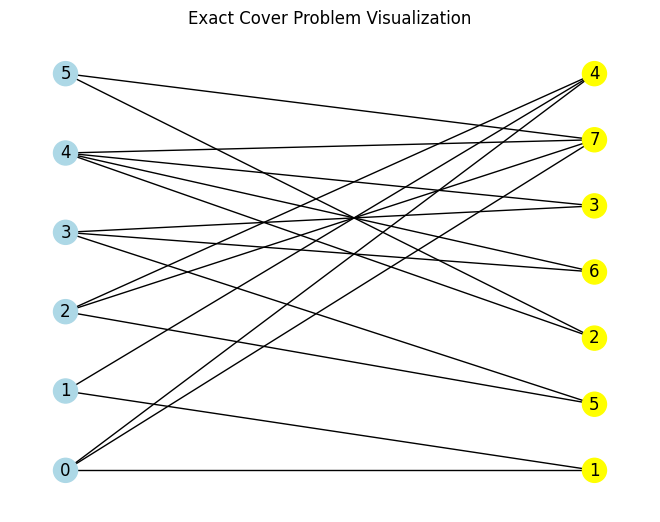

In [3]:
ec = EC.from_preset('default')
ec.visualize()

As you can see you can easily visualize the problem instance by calling visualize() method, you can can also visualize an example solution.

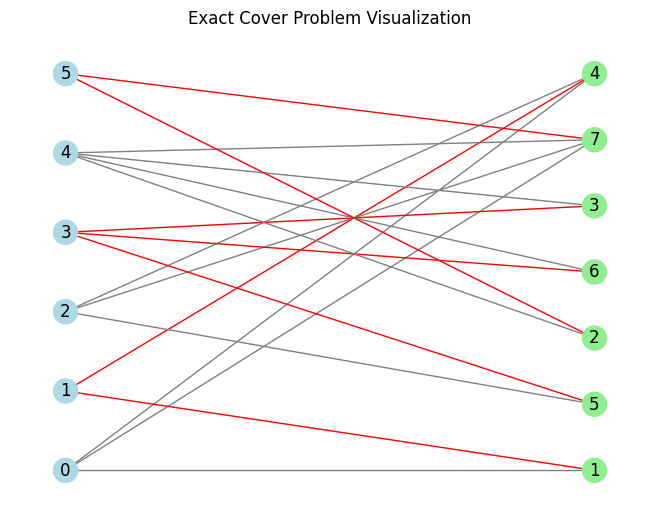

In [4]:
ec.visualize('010101')

Problem instances can be also randomly generated. 

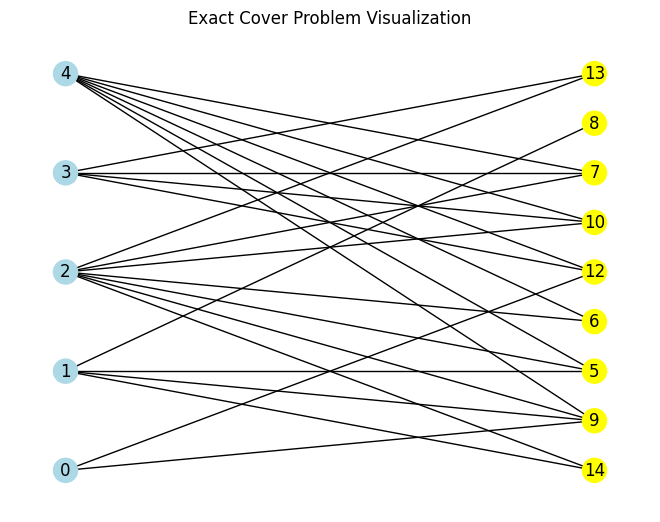

In [5]:
ec = EC.generate_ec_instance(5, 10, 0.4)
ec.visualize()

All problems problems already implemented in the QLauncher are presented below:

## Max Cut
Max Cut is a combinatorial optimization problem in which the goal is to separate graph vertices into two subsets such that the number of edges connecting vertices in different subsets (called a _cut_) is maximized.

Formally, solving a max Cut problem is equivalent to minimizing cost function 

$$\min C(x) = \sum_{i,j}x_{i}(1-x_{j}) $$

where $x_{i} = 0$ if vertex x belongs to first subset and $x_{i}=1$ if vertex x belongs to the second subset.

the bits in the encoding of solution correspond to the assignment of the respective vertices.

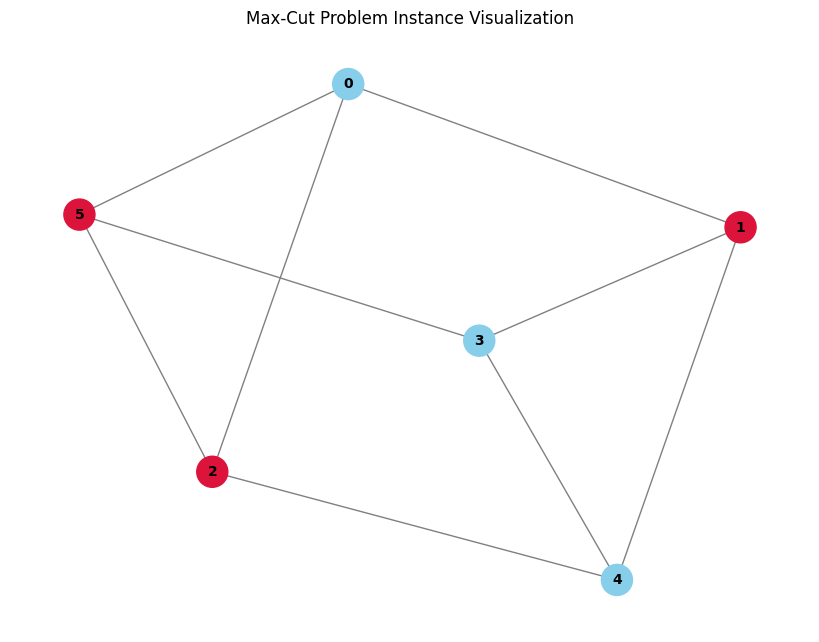

In [6]:
mc = MaxCut.from_preset('default')
mc.visualize('011001')

## Exact Cover

Let $X$ be a set, and $F$ a family of all its subsets. Exact cover is then a subfamily $F^*$ of $F$ such that each element in $X$ is contained in exactly one of the subsets in $F^*$.

To solve the exact cover problem means to choose from the whole family $F$ of subsets of some set $X$ a subfamily $F^*$ such that each element in $X$ is contained in exactly exactly one of the subsets in $F^*$.

In other words the selected subfamily $F^*$ must satisfy the following two conditions:

1. The intersection of any two distinct subsets from $F^*$ is empty.
2. The union of all subsets from is equal to $X$, these subsets _cover_ the set $X$.

It can be visualized on a bipartite graph such that elements from the left set represent the subsets and elements from the right set represent the elements in $X$. In this case solving the the exact cover problem is equivalent to finding a subset of elements from the left set such that each element from the right one is connected to exactly one element from the the selected subset.

in the encoding of the solution each bit represents a subset (or node from the left set in the bipartite representation), $1$ indicates that such subset/node is chosen.

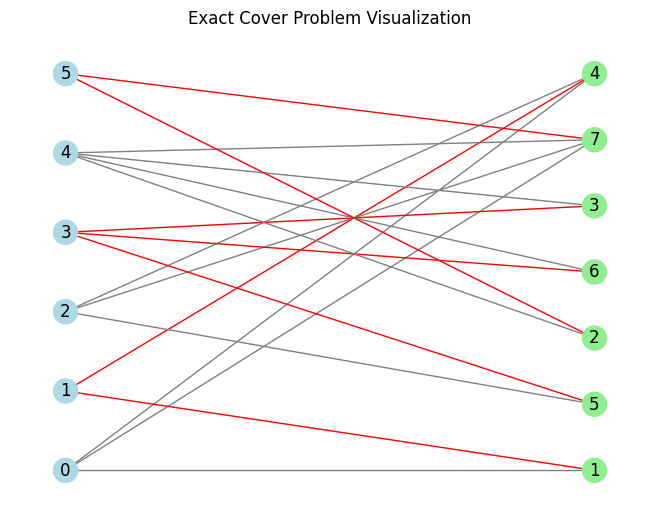

In [7]:
ec = EC.from_preset('default')
ec.visualize('010101')

## Traveling Salesman
Traveling salesman problem is defined as follows: "Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city". 

It gets easily visualized by a weighted graph where nodes represent cities while weights represent distances between them. 

Essentially finding a solution to the Traveling Salesman Problem ie equivalent to finding a permutation of nodes such that the sum of weights associated with edges connecting ech two consecutive nodes is the lowest, i.e. minimizing the objective function:

$$\min C(v) = \sum_{i=1}^{n-1}dist(v_{i},v_{i+1})$$

where $v_{1...n}$ denotes a sequence of nodes such that:

$$\forall_{i,j}(i \not= j) =>(v_{i} \not= v_{j})$$

In QLauncher encoding a solution to the $N$-node problem uses $N^2$ bits grouped into $N$-bit substrings where each substring denotes, by the use of one-hot-encoding, which node was chosen at a given position in the sequence.

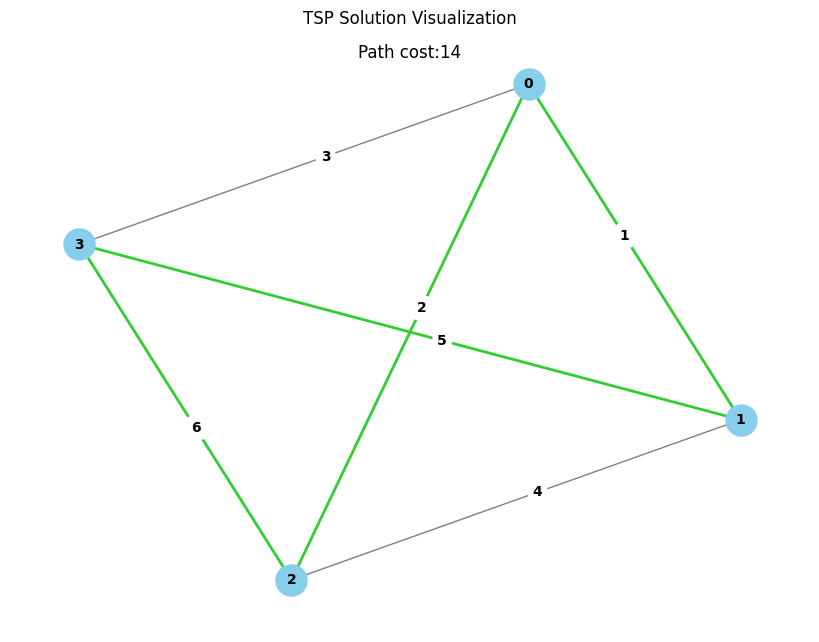

In [8]:
tsp = TSP.from_preset('default')
tsp.visualize('0100100000100001')

## Graph Coloring


Graph coloring refer to the assigning of labels to the graph's vertices  such that no two vertices sharing the same edge have the same label, although for visualization purposes labels in the form of colors are often used they can generally be of any form. Specifically $k$-coloring is a graph coloring which uses at most $k$ distinct colors. 

QLauncher implements Minimum Conflict Graph Coloring, an optimization version of the $k$-coloring in which given $k$ available colors the goal is to assign colors to vertices such that a proper coloring is obtained or that the number of occurring conflicts is the lowest, i.e. minimize the objective function:

$$\min C(x)=\sum_{(i, j) \in E} \delta(x_i, x_j)$$

$$\quad \text{where} \quad
\delta(x_i, x_j) = 
\begin{cases}
1 & \text{if } x_i = x_j \\
0 & \text{if } x_i \ne x_j
\end{cases}$$

and x is a sequence of colors such that: 

$$\forall_{i} x_{i}\in{1...k}$$

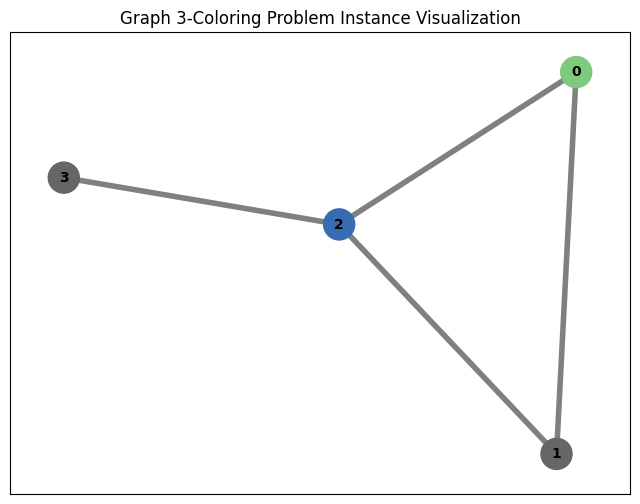

In [9]:
gc = GraphColoring.from_preset('small')
gc.visualize([0, 2, 1, 2])

## Vertex Cover

Vertex Cover problem refers to choosing subset of vertices, of minimal possible size, such that each edge has at least one of its endpoints in the chosen subset.
The goal can be represented as minimizing a cost function:

$$\min C(x)=\sum_{k \in N} v_k + \sum_{(i, j) \in E} 1-v_i-v_j+v_i*v_j $$
$$\quad \text{where} \quad
v_i = 
\begin{cases}
1 & \text{if } \text{vertex i belongs to the chosen subset} \\
0 & \text{if } \text{vertex i does not belong to the chosen subset}
\end{cases}$$

The first term of this formulation encourages minimization of subset size while the second ensures constraint satisfaction.

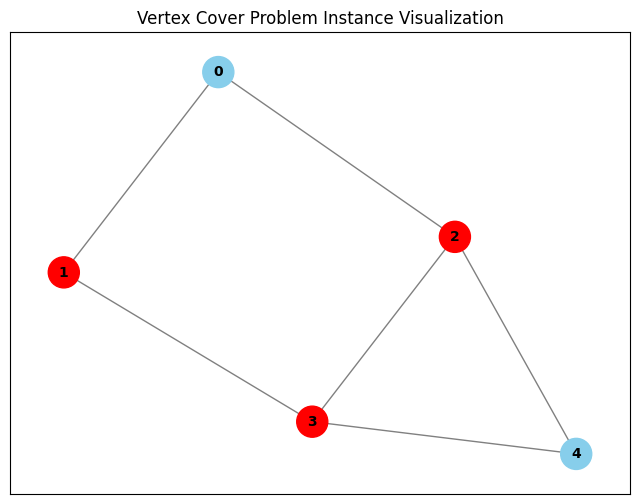

In [10]:
gc = VertexCover.from_preset('default')
gc.visualize([0, 1, 1, 1, 0])


## Air Traffic Management

Air Traffic management is a combinatorial optimization problem in which a group of aircraft fly through a common airspace, each of them can perform one of the available maneuvers, some of which will result in collision with other aircraft. The goal is to choose a maneuver for every aircraft such that the minimal number of collisions occur.

It can be represented as minimizing a cost function:

$$\min C(x) = \sum_i \sum_m \sum_{j>i} \sum_n (x_{im}*x_{jn} *CM_{imjn}) + \sum_i (1- \sum_m x_{im} )^2$$

where $x_{im}$ denotes that aircraft $i$ performs maneuver $m$ and $CM$ is a collision matrix filled with ones and zeros. If $CM_{imjn}$ is 1 then we know that aircraft $i$ performing maneuver $m$ collides with aircraft $j$ performing maneuver $n$. Minimizing the first part $\min C(x) = \sum_i \sum_m \sum_{j>i} \sum_n (x_{im}*x_{jn} *CM_{imjn})$ is equivalent to minimizing the number of collisions while the second part $\sum_i (1- \sum_m x_{im} )^2$ enforces the constraint that each aircraft should perform exactly one maneuver.

Input to the problem consists of table of maneuvers available for each aircraft and the matrix of collisions.

In the example below each aircraft has 2 maneuvers available to them represented by "Ax" and "Ax_a=10" where x is an index of the aircraft. When encoded in bitstrings maneuvers are indexed just like in this table e.g. 1 at 0th position means that aircraft no. 0 takes the first from its two maneuvers and 1 at 4th position mean that aircraft no. 1 takes the second of its maneuvers.

In [11]:
filepath = os.path.abspath('./../data/qatm/')
atm = QATM.from_file(filepath, 'RCP_3.txt')

print('Aircraft manouvers')
print(atm.aircrafts)

Aircraft manouvers
  manouver aircraft
0       A0       A0
1       A1       A1
2       A2       A2
3  A0_a=10       A0
4  A1_a=10       A1
5  A2_a=10       A2


The collision matrix which combinations of maneuvers would result in a collision and should be avoided, 1 at $i$'th column and $j$'th row indicates that maneuvers i and j happening together result in a collision.

In [12]:
print('Collisions')
print(atm.cm)

Collisions
[[1. 0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 1.]
 [1. 0. 1. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 1. 0.]
 [0. 1. 0. 0. 0. 1.]]


The proposed encoding means that the aforementioned additional constraint needs to be introduced in order to keep the solutions valid, exactly one of the bits which correspond to maneuvers of a single aircraft must be set to 1, the rest set to 0. The example of a valid solution which results in no collision is presented below:

In [13]:
print(atm.analyze_result({'011100': 1, '000111': 1}))

{'collisions': array([0., 0.]), 'onehot_violations': array([0, 0]), 'changes': array([1, 3]), 'at_least_one': array([1, 1])}


## Job Shop Scheduling
Job-shop scheduling belongs to a family of optimal job scheduling problems, problems in which we are given n jobs $J_1, J_2, ..., J_n$ of varying processing times and need to schedule them on $m$ machines so that the total length of the schedule, so called makespan, is the lowest. 

In Job-shop scheduling specifically each job consists of of a set of operations $O_1, O_2, ..., O_n$, each of them with its own processing time and a dedicated machines, which need to be processed in a specific order.

In [14]:
jssp = JSSP.from_preset('default')
jssp.instance

{'cupcakes': [('mixer', 2), ('oven', 1)],
 'smoothie': [('mixer', 1)],
 'lasagna': [('oven', 2)]}

In this specific example we have 3 jobs: cupcakes, smoothie and lasagna. Cupcakes needs to be processed for 2 time units in a mixer and 1 time unit in an oven, smoothie needs 1 time unit in the mixer and lasagna 2 time units in the oven. Additionally we put a limit of 3 time units on the solutions to this problem.

In [15]:
jssp.max_time

3

Solutions to the Job-shop scheduling problem are encoded in a way that bit 1 represents task (job's operation) $i$ being scheduled to begin on time slot $j$ on its dedicated machine where $i$ and $j$ are associated with the bit's position. Bits are ordered first by the task's number and then by the time slot. 

Solutions to the JSSP formulated this way would need to be $n*m$ bits long where $n$ stands for number of tasks and $m$ for number of available time slots. However since not all assignments are possible we can optimize this encoding in decrease the bitstrings' length. First task cannot be scheduled earlier than sum of processing times of its preceding tasks and cannot be scheduled to start later than sum of it's processing time and processing times of it's succeeding tasks. We can therefore remove bits representing infeasible assignments from the bitstring to make problem solvable with lower number of qubits. 

For example for the example above the theoretical required number of bits is 12 (4 tasks * 3 time slots) but we can optimizer it to just 7 bits. There is only one possible assignment for the first and second task of the first job so they get 1 bit each, smoothie can start getting processed in the mixer in time slots 1, 2 or 3 so 3 bits, a lasagna can start getting processed only in time slots 1 and 2 (2 bits).

The example assignment of "1100110" tells us to schedule cupcake tasks each to it's only feasible time slot (first 2 bits), then schedule processing smoothie in the mixer at 3rd time slot (3rd bit equal to 1) and last but not least schedule putting lasagna in the oven to the 2nd time slot, this is actually the optimal assignment.